#                                   Maximizing Revenue for Taxi Cab Drivers through Payment Type Analysis

**Problem Statement**

In the fast-paced taxi booking sector, making the most of revenue is essential for long-term success and driver happiness. Our goal is to use data-driven insights to maximise revenue streams for taxi drivers in order to meet this need. Our research aims to determine whether payment methods have an impact on fare pricing by focusing on the relationship between payment type and fare amount.

**Objective**

This project's main goal is to run an A/B test to examine the relationship between the total fare and the method of payment. We use Python hypothesis testing and descriptive statistics to extract useful information that can help taxi drivers generate more cash. In particular, we want to find out if there is a big difference in the fares for those who pay with credit cards versus those who pay with cash.

**Research Question**

Is there a relationship between total fare amount and payment type and can we nudge customers towards payment methods that generate higher revenue for drivers, without negatively impacting customer experience?


# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings 
warnings.filterwarnings('ignore')

# Loading Dataset

In [2]:
df = pd.read_csv("2023_Yellow_Taxi_Trip_Data.csv")
df.head(8)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01-01-2023 00:32,01-01-2023 00:40,1,0.97,1,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,01-01-2023 00:55,01-01-2023 01:01,1,1.10,1,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,01-01-2023 00:25,01-01-2023 00:37,1,2.51,1,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,01-01-2023 00:03,01-01-2023 00:13,0,1.90,1,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,01-01-2023 00:10,01-01-2023 00:21,1,1.43,1,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00
5,2,01-01-2023 00:50,01-01-2023 01:02,1,1.84,1,N,161,137,1,12.8,1.00,0.5,10.00,0.0,1.0,27.80,2.5,0.00
6,2,01-01-2023 00:09,01-01-2023 00:19,1,1.66,1,N,239,143,1,12.1,1.00,0.5,3.42,0.0,1.0,20.52,2.5,0.00
7,2,01-01-2023 00:27,01-01-2023 00:49,1,11.70,1,N,142,200,1,45.7,1.00,0.5,10.74,3.0,1.0,64.44,2.5,0.00


# EDA

In [3]:
df.shape

(1048575, 19)

In [4]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='mixed')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'],  format='mixed')


In [5]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [6]:
df['Duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [7]:
df[df.duplicated()].count()

VendorID                 34
tpep_pickup_datetime     34
tpep_dropoff_datetime    34
passenger_count          34
trip_distance            34
RatecodeID               34
store_and_fwd_flag       34
PULocationID             34
DOLocationID             34
payment_type             34
fare_amount              34
extra                    34
mta_tax                  34
tip_amount               34
tolls_amount             34
improvement_surcharge    34
total_amount             34
congestion_surcharge     34
airport_fee              34
Duration                 34
dtype: int64

In [8]:
df = df.drop_duplicates()

In [9]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Duration
0,2,2023-01-01 00:32:00,2023-01-01 00:40:00,1,0.97,1,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00,8.0
1,2,2023-01-01 00:55:00,2023-01-01 01:01:00,1,1.10,1,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00,6.0
2,2,2023-01-01 00:25:00,2023-01-01 00:37:00,1,2.51,1,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00,12.0
3,1,2023-01-01 00:03:00,2023-01-01 00:13:00,0,1.90,1,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25,10.0
4,2,2023-01-01 00:10:00,2023-01-01 00:21:00,1,1.43,1,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,2,2023-01-12 17:20:00,2023-01-12 17:29:00,1,2.38,1,N,132,10,1,12.8,2.50,0.5,0.00,0.0,1.0,18.05,0.0,1.25,9.0
1048571,2,2023-01-12 17:49:00,2023-01-12 18:28:00,1,8.20,1,N,132,131,2,41.5,2.50,0.5,0.00,0.0,1.0,46.75,0.0,1.25,39.0
1048572,1,2023-01-12 17:03:00,2023-01-12 17:30:00,1,5.50,1,N,163,45,1,26.8,5.00,0.5,4.99,0.0,1.0,38.29,2.5,0.00,27.0
1048573,1,2023-01-12 17:35:00,2023-01-12 17:35:00,1,0.00,1,Y,87,264,2,7.9,5.00,0.5,0.00,0.0,1.0,14.40,2.5,0.00,0.0


In [10]:
df = df[['passenger_count','trip_distance','payment_type','fare_amount','Duration']]
df

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,0.97,2,9.3,8.0
1,1,1.10,1,7.9,6.0
2,1,2.51,1,14.9,12.0
3,0,1.90,1,12.1,10.0
4,1,1.43,1,11.4,11.0
...,...,...,...,...,...
1048570,1,2.38,1,12.8,9.0
1048571,1,8.20,2,41.5,39.0
1048572,1,5.50,1,26.8,27.0
1048573,1,0.00,2,7.9,0.0


In [11]:
df.isnull().sum()

passenger_count    0
trip_distance      0
payment_type       0
fare_amount        0
Duration           0
dtype: int64

In [12]:
df[df.duplicated()]

,passenger_count,trip_distance,payment_type,fare_amount,Duration
255,2,2.30,1,13.5,13.0
378,1,0.47,1,5.1,3.0
406,1,1.60,1,9.3,7.0
447,1,0.80,1,5.8,3.0
480,2,2.30,1,13.5,13.0
...,...,...,...,...,...
1048569,2,2.80,1,21.9,23.0
1048570,1,2.38,1,12.8,9.0
1048572,1,5.50,1,26.8,27.0
1048573,1,0.00,2,7.9,0.0


In [13]:
(742173/len(df))*100

70.781495430317

In [14]:
df2 = df.copy()
df2 = df2.drop_duplicates()


In [15]:
df2.shape

(306368, 5)

In [16]:
df2["passenger_count"].value_counts(normalize = True)

passenger_count
1    0.573177
2    0.215022
3    0.078043
4    0.052222
5    0.034390
6    0.024471
0    0.022672
8    0.000003
Name: proportion, dtype: float64

In [17]:
df2['payment_type'].value_counts(normalize = True)

payment_type
1    0.671369
2    0.284645
4    0.030731
3    0.013255
Name: proportion, dtype: float64

In [18]:
df2 = df2[df2['payment_type']<3]
df2 = df2[(df2['passenger_count']>0) & (df2['passenger_count']<6)]


In [19]:
df2.shape

(278946, 5)

In [20]:
df2['payment_type'].replace([1,2], ["card", "cash"], inplace =True)
df2

,passenger_count,trip_distance,payment_type,fare_amount,Duration
0,1,0.97,cash,9.3,8.0
1,1,1.10,card,7.9,6.0
2,1,2.51,card,14.9,12.0
4,1,1.43,card,11.4,11.0
5,1,1.84,card,12.8,12.0
...,...,...,...,...,...
1048542,1,4.50,card,28.9,34.0
1048546,3,2.39,card,17.0,16.0
1048550,1,16.64,card,70.0,73.0
1048555,1,0.55,card,7.2,1386.7


In [21]:
df2 = df2[df2['trip_distance']>0]
df2 = df2[df2['fare_amount']>0]
df2 = df2[df2['Duration']>0]

In [22]:
df2.describe()

,passenger_count,trip_distance,fare_amount,Duration
count,272986.000000,272986.000000,272986.000000,272986.000000
mean,1.717795,7.601031,34.309493,28.740832
std,1.078927,37.596014,24.251669,80.861097
min,1.000000,0.010000,0.010000,0.050000
25%,1.000000,2.500000,17.000000,14.000000
50%,1.000000,5.180000,26.800000,21.000000
75%,2.000000,10.750000,46.400000,31.000000
max,5.000000,9680.610000,656.800000,3041.000000


#                                                   Remove Outilers By IQR

In [23]:
# for col in['trip_distance','fare_amount','Duration']:
#     Q1 = df2[col].quantile(0.25)
#     Q3 = df2[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower_bound = Q1 - 1.5*IQR
#     upper_bound = Q3 + 1.5*IQR

#     df2 = df2[(df2[col]>= lower_bound) & (df2[col]<= upper_bound)]

In [24]:
for col in ['trip_distance','fare_amount','Duration']:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df2 = df2[df2[col].between(lower, upper)]

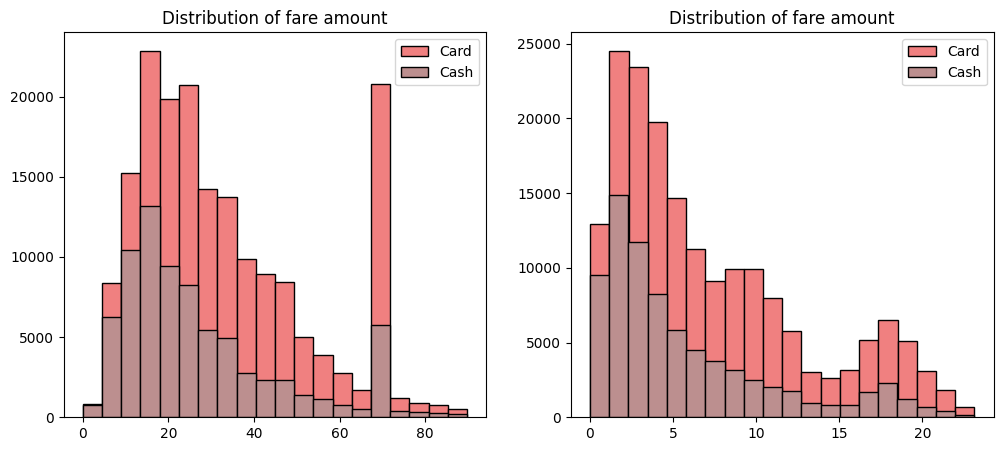

In [25]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('Distribution of fare amount')
plt.hist(df2[df2['payment_type']=='card']['fare_amount'], histtype='barstacked', bins=20,edgecolor='k', color='lightcoral', label='Card')
plt.hist(df2[df2['payment_type']=='cash']['fare_amount'],histtype='barstacked', bins=20,edgecolor='k', color='rosybrown', label='Cash')
plt.legend()


plt.subplot(1,2,2)
plt.title('Distribution of fare amount')
plt.hist(df2[df2['payment_type']=='card']['trip_distance'],histtype='barstacked', bins=20,edgecolor='k', color='lightcoral', label='Card')
plt.hist(df2[df2['payment_type']=='cash']['trip_distance'],histtype='barstacked', bins=20,edgecolor='k', color='rosybrown', label='Cash')
plt.legend()

plt.show()

In [26]:
df2.groupby('payment_type').agg({'fare_amount': ['mean', 'std'] , 'trip_distance': ['mean', 'std']})

fare_amount            trip_distance          
                    mean        std          mean       std
payment_type                                               
card           33.277747  19.926107      7.208131  5.657920
cash           27.527889  18.859432      5.701077  5.190561

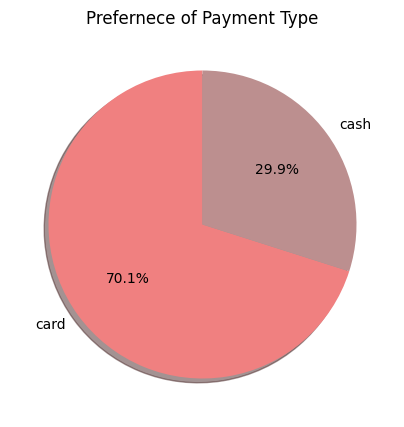

In [32]:
plt.figure(figsize=(5,5))
plt.title('Prefernece of Payment Type')
plt.pie(df2['payment_type'].value_counts(normalize = True), labels = df2['payment_type'].value_counts().index, startangle = 90 
        , shadow = True, autopct = '%1.1f%%', colors = ['lightcoral' , 'rosybrown'])
plt.show()
        

In [37]:
passenger_count = df2.groupby(['payment_type', 'passenger_count']) [['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count': 'count'}, inplace = True)
passenger_count.reset_index(inplace = True)

In [39]:
passenger_count['perc'] = passenger_count['count'] / passenger_count['count'].sum() *100

In [40]:
passenger_count

,payment_type,passenger_count,count,perc
0,card,1,105965,41.130532
1,card,2,41882,16.256584
2,card,3,15434,5.990739
3,card,4,9553,3.708017
4,card,5,7733,3.001580
5,cash,1,45904,17.817732
6,cash,2,17193,6.673498
7,cash,3,6507,2.525705
8,cash,4,5009,1.944254
9,cash,5,2451,0.951361


#       Passenger Count Analysis

• Among card payments, rides with a single passenger (passenger_count = 1) comprise the largest proportion, constituting 41.1% of all card transactions.

• Similarly, cash payments are predominantly associated with single-passenger rides, making up 17.8% of all cash transactions.

• There is a noticeable decrease in the percentage of transactions as the passenger count increases, suggesting that larger groups are less likely to use taxis or may opt for alternative payment methods.

• These insights emphasize the importance of considering both payment method and passenger count when analyzing transaction data, as they provide valuable insights into customer behavior and preferences.


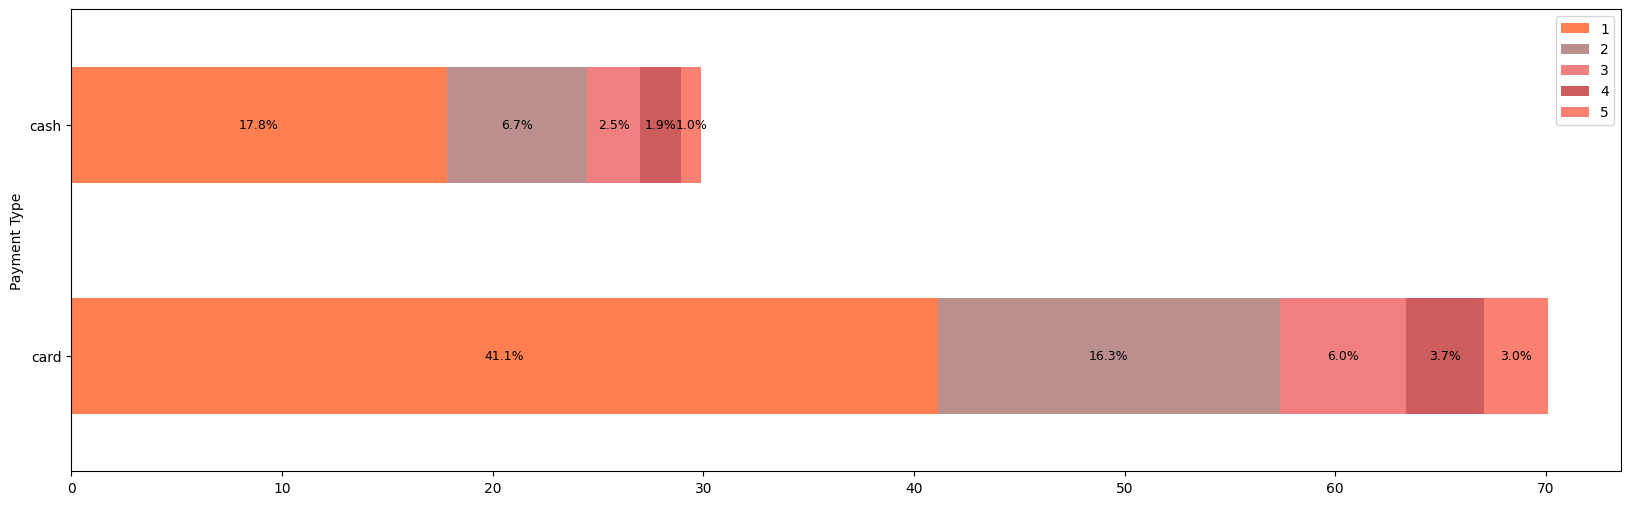

In [53]:
pivot = passenger_count.pivot(index='payment_type',
                              columns='passenger_count',
                              values='perc')
ax = pivot.plot(kind='barh',
                stacked=True,
                figsize=(20,6),
                color=['coral','rosybrown','lightcoral','indianred','salmon'])
plt.ylabel("Payment Type")

# ✅ Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, color='black')

plt.legend(bbox_to_anchor=(1,1))
plt.show()

**Null Hypothesis** : There is no difference in average fare between customer who use credit card and customer who use cash.

**Alternative Hypothesis** : There is difference in average fare between customer who use credit card and customer who use cash.

In [60]:
import statsmodels.api as sm

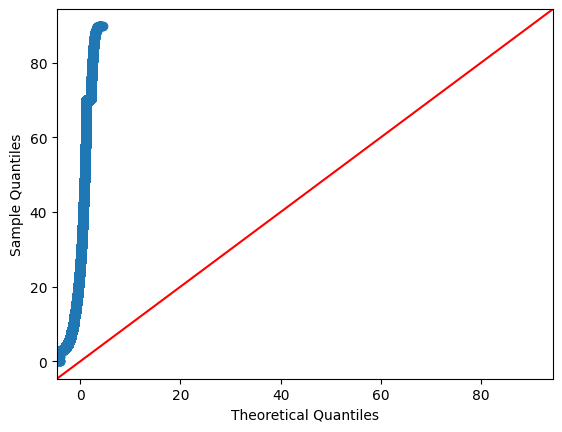

In [61]:
# It is use to check my data is normally distributed because it is then i can perform T-test hypothesis. Is data line overlaps line (angle = 45).
sm.qqplot(df2['fare_amount'] ,line = '45')
plt.show()

In [68]:
card_sample = df2[df2['payment_type'] == 'card']['fare_amount']
cash_sample = df2[df2['payment_type'] == 'cash']['fare_amount']

In [69]:
# now i use z-score tesing 
from scipy import stats as st
t_stats,p_value =  st.ttest_ind( a = card_sample, b = cash_sample, equal_var = False)
print('T_statistics', t_stats, 'p_value', p_value)

T_statistics 69.65424409213762 p_value 0.0


**Result states that null hypothesis has rejected, & it show difference  average fare between customer who use credit card & customer who use cash**